In [1]:
!pip install transformers==4.28.0
!pip install datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 46.0 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.20.0
    Uninstalling transformers-4.20.0:
      Successfully uninstalled transformers-4.20.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 15.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 18.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 26.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 18.9 MB/s eta 0:00:00


In [2]:
import re
import string
import tensorflow as tf

In [3]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoTokenizer
from transformers import AdamW, get_linear_schedule_with_warmup, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [4]:
train = pd.read_csv("/content/train_target_dataset.csv")
validation = pd.read_csv("/content/validation_target_dataset.csv")
test = pd.read_csv("/content/test_target_dataset.csv")

In [5]:
import datasets
import pandas as pd
from datasets import Dataset, DatasetDict

train_df = pd.DataFrame({
     "text" : train["Translated_Text"],
     "labels" : train['Targets (1-Individual, 0-Group)']

})
val_df = pd.DataFrame({
     "text" : validation["Translated_Text"],
     "labels" : validation['Targets (1-Individual, 0-Group)']

})

test_df = pd.DataFrame({
     "text" : test["Translated_Text"],
     "labels" : test['Targets (1-Individual, 0-Group)']

})

train_dataset = Dataset.from_dict(train_df)
val_dataset = Dataset.from_dict(val_df)
test_dataset = Dataset.from_dict(test_df)
dataset = datasets.DatasetDict({"train":train_dataset,"validation":val_dataset,"test":test_dataset})

In [6]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 430
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 48
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 120
    })
})

In [7]:
dataset.num_rows

{'train': 430, 'validation': 48, 'test': 120}

In [8]:
dataset['train'][0]

{'text': 'θα πολεμήσουμε κάθε εχθρική δύναμη μέχρι την τελευταία μας πνοή είτε είναι η ινδία είτε το ισραήλ',
 'labels': 0}

In [9]:
train.head()

,Tweets,"Targets (1-Individual, 0-Group)",Translated_Text
0,we will fight every enemy force till our last ...,0,θα πολεμήσουμε κάθε εχθρική δύναμη μέχρι την τ...
1,god willing dogs will die they will ask for de...,0,θεού θέλοντος τα σκυλιά θα πεθάνουν θα ζητήσου...
2,who is this patwari tell me so that i must tea...,1,ποιος είναι αυτός ο πατουάρι πείτε μου ώστε να...
3,where will they have so much courage to break ...,0,πού θα έχουν τόσο κουράγιο να σπάσουν τα πόδια...
4,hit me you dog bastard come swat and kill me i...,1,χτύπησε με μπάσταρδε σκύλε έλα να με χτυπήσεις...


In [10]:
test.head()

,Tweets,"Targets (1-Individual, 0-Group)",Translated_Text
0,kashmir will become pakistan india will live i...,0,το κασμίρ θα γίνει πακιστάν η ινδία θα ζήσει σ...
1,thieves miscreants escaped from the court this...,0,οι κλέφτες οι παραβάτες διέφυγαν από το δικαστ...
2,the people who will fight against the pakistan...,0,οι άνθρωποι που θα πολεμήσουν εναντίον του πακ...
3,india has threatened war and invited its own d...,0,η ινδία έχει απειλήσει με πόλεμο και έχει προκ...
4,a stone will be answered by a brick captain on...,1,μια πέτρα θα απαντηθεί με ένα τούβλο καπετάνιο...


In [11]:
validation.head()

,Tweets,"Targets (1-Individual, 0-Group)",Translated_Text
0,his so much courage make it a lesson so that i...,1,το τόσο μεγάλο του θάρρος κάντε το μάθημα ώστε...
1,remember this person will lead imran niazi to ...,1,θυμηθείτε αυτό το άτομο θα οδηγήσει τον ιμράν ...
2,shut your mouth son of a bitch not a karachi h...,0,κλείσε το στόμα σου πουτάνας γιε ούτε ένα καρά...
3,whosoever patwari messes up in nab office cut ...,0,όποιος πατουάρι κάνει μπάχαλο στο γραφείο του ...
4,hijra stop cruelty in kashmir otherwise it wil...,1,χίτζρα σταματήστε την βαναυσότητα στο κασμίρ δ...


#Hyperparameters

In [12]:
num_epoch = 10
sq_len = 128
batch_size = 32
lr_rate = 3e-5
epsilon = 1e-8
hidden_dropout = 0.05
warmup_ratio = 0.01
weight_decay = 0.01

In [13]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('setu4993/LaBSE')

def encode_batch(batch):
  """Encodes a batch of input data using the model tokenizer."""
  return tokenizer(batch["text"], max_length=sq_len, truncation=True, padding="max_length")

# Encode the input data
dataset = dataset.map(encode_batch, batched=True)
# The transformers model expects the target class column to be named "labels"
#dataset.rename_column_("label", "labels")
# Transform to pytorch tensors and only output the required columns
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/367 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/5.22M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/13.6M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Map:   0%|          | 0/430 [00:00<?, ? examples/s]

Map:   0%|          | 0/48 [00:00<?, ? examples/s]

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

In [14]:
# Calculation of the maximum length of any text in terms of tokens

max_len = 0

# Concatenate all datasets
all_texts_df = pd.concat([train["Translated_Text"], validation["Translated_Text"], test["Translated_Text"]])

# Iterate through each text in the dataset
for text in all_texts_df:
    input_ids = tokenizer.encode(text, add_special_tokens=True)
    max_len = max(max_len, len(input_ids))

print(f"The maximum length of any text in terms of tokens is: {max_len}")


The maximum length of any text in terms of tokens is: 110


In [15]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 430
    })
    validation: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 48
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 120
    })
})

## Training

In [16]:
from transformers import AutoConfig, AutoModelForSequenceClassification

# Model and training configuration
config = AutoConfig.from_pretrained('setu4993/LaBSE',
                                    num_labels=2,
                                    problem_type="single_label_classification")

config.hidden_dropout_prob = hidden_dropout
model = AutoModelForSequenceClassification.from_pretrained('setu4993/LaBSE', config=config)

config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/1.88G [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at setu4993/LaBSE and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [17]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [18]:
# Define the function to compute the metrics during evaluation
from sklearn.metrics import accuracy_score, precision_recall_fscore_support,precision_score,recall_score,confusion_matrix
import time
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    precision = precision_score(labels, preds, average='weighted',zero_division=0)
    recall = recall_score(labels, preds, average='weighted',zero_division=0)
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall, 'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn}



In [19]:
optimizer = AdamW(model.parameters(), lr=lr_rate, eps=epsilon)
total_steps = len(dataset["train"]) * num_epoch
warmup_steps = int(total_steps * warmup_ratio)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [20]:
from datetime import datetime
import pandas as pd

# Create empty lists to store results
epoch_list = []
training_loss_list = []
validation_loss_list = []
training_time_list = []
validation_time_list = []
validation_accuracy_list = []
validation_f1_list = []

test_tp_list = []
test_tn_list = []
test_fp_list = []
test_fn_list = []

test_accuracy_list = []
test_f1_list = []
test_precision_list = []
test_recall_list = []
# Define the trainer Arguments
training_args = TrainingArguments(
          output_dir='./results',
          overwrite_output_dir='True',
          num_train_epochs=1,
          per_device_train_batch_size=batch_size,
          per_device_eval_batch_size=batch_size,
          warmup_ratio=warmup_ratio,
          weight_decay=weight_decay,
          logging_dir='./logs',
          logging_steps=100,
          save_strategy='no',
          evaluation_strategy='no',
          load_best_model_at_end=True,
          metric_for_best_model='accuracy',
          greater_is_better=True,


    )

train_epoch = num_epoch
# Train the model and track the metrics after each epoch
for epoch in range(train_epoch):


    # Define the trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=dataset["train"],
        eval_dataset=dataset["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        # optimizers=(optimizer, None)
    )


    # Train the model for one epoch
    start_time = datetime.now()
    train_result = trainer.train()
    end_time = datetime.now()

    # Perform optimization steps
    optimizer.step()


    # Clear gradients
    optimizer.zero_grad()

    # Perform evaluation on the validation set
    validation_result = trainer.evaluate(eval_dataset=dataset["validation"])

    # Perform evaluation on the test set
    test_result = trainer.evaluate(eval_dataset=dataset["test"])


    # Extract the desired information
    training_loss = train_result.training_loss
    validation_loss = validation_result["eval_loss"]

    validation_time = validation_result["eval_runtime"]
    training_time = train_result.metrics["train_runtime"]

    validation_accuracy = validation_result["eval_accuracy"]
    validation_f1 = validation_result["eval_f1"]


    test_accuracy = test_result["eval_accuracy"]
    test_f1 = test_result["eval_f1"]
    test_precision = test_result["eval_precision"]
    test_recall = test_result["eval_recall"]

    test_tp = test_result["eval_tp"]
    test_tn = test_result["eval_tn"]
    test_fp = test_result["eval_fp"]
    test_fn = test_result["eval_fn"]

    val_runtime_formatted = pd.to_datetime(validation_time, unit='s').strftime('%H:%M:%S')
    train_runtime_formatted = pd.to_datetime(training_time, unit='s').strftime('%H:%M:%S')

    # Append the metrics to the respective lists
    epoch_list.append(epoch + 1)
    training_loss_list.append(training_loss)
    validation_loss_list.append(validation_loss)

    validation_accuracy_list.append(validation_accuracy)
    validation_f1_list.append(validation_f1)

    training_time_list.append(train_runtime_formatted)
    validation_time_list.append(val_runtime_formatted)

    test_tp_list.append(test_tp)
    test_tn_list.append(test_tn)
    test_fp_list.append(test_fp)
    test_fn_list.append(test_fn)


    test_accuracy_list.append(test_accuracy)
    test_f1_list.append(test_f1)
    test_precision_list.append(test_precision)
    test_recall_list.append(test_recall)

# Create a DataFrame to store the results
train_df = pd.DataFrame({
    "Epoch": epoch_list,
    "Training Loss": training_loss_list,
    "Validation Loss": validation_loss_list,
    "Validation Accuracy": validation_accuracy_list,
    "Validation F1": validation_f1_list,
    "Training Time": training_time_list,
    "Validation Time": validation_time_list,
})

test_df = pd.DataFrame({
    "Epoch": epoch_list,
    "Test TP": test_tp_list,
    "Test TN": test_tn_list,
    "Test FP": test_fp_list,
    "Test FN": test_fn_list,
    "Test Accuracy": test_accuracy_list,
    "Test F1": test_f1_list,
    "Test Precision": test_precision_list,
    "Test Recall": test_recall_list,
})

You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Step,Training Loss


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Step,Training Loss


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


...

Step,Training Loss


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Step,Training Loss


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Step,Training Loss


In [21]:
train_df.head(10)

,Epoch,Training Loss,Validation Loss,Validation Accuracy,Validation F1,Training Time,Validation Time
0,1,0.653169,0.630500,0.645833,0.645680,00:00:07,00:00:00
1,2,0.484200,0.609856,0.687500,0.687364,00:00:05,00:00:00
2,3,0.351295,0.784995,0.645833,0.644444,00:00:05,00:00:00
3,4,0.279796,0.984165,0.666667,0.664336,00:00:05,00:00:00
4,5,0.270417,1.421523,0.708333,0.707826,00:00:05,00:00:00
5,6,0.253082,1.871325,0.645833,0.645680,00:00:05,00:00:00
6,7,0.240345,2.353822,0.729167,0.726196,00:00:05,00:00:00
7,8,0.261891,2.590088,0.604167,0.603995,00:00:05,00:00:00
8,9,0.212468,2.800153,0.666667,0.666087,00:00:05,00:00:00
9,10,0.156871,3.050492,0.604167,0.603995,00:00:05,00:00:00


In [22]:
test_df.head(10)

,Epoch,Test TP,Test TN,Test FP,Test FN,Test Accuracy,Test F1,Test Precision,Test Recall
0,1,42,39,21,18,0.675000,0.674797,0.675439,0.675000
1,2,42,41,19,18,0.691667,0.691645,0.691720,0.691667
2,3,39,44,16,21,0.691667,0.691130,0.693007,0.691667
3,4,46,41,19,14,0.725000,0.724522,0.726573,0.725000
4,5,48,43,17,12,0.758333,0.757913,0.760140,0.758333
5,6,47,41,19,13,0.733333,0.732665,0.735690,0.733333
6,7,49,39,21,11,0.733333,0.731469,0.740000,0.733333
7,8,45,50,10,15,0.791667,0.791304,0.793706,0.791667
8,9,49,44,16,11,0.775000,0.774609,0.776923,0.775000
9,10,47,45,15,13,0.766667,0.766602,0.766963,0.766667


## SHAP

In [23]:
!pip install shap

In [24]:
import scipy as sp
import numpy as np
import torch
import shap

# Prediction function
def f(x):
    tv = torch.tensor(
        [
            tokenizer.encode(v, padding="max_length", max_length=128, truncation=True)
            for v in x
        ]
    ).cuda()
    outputs = model(tv)[0].detach().cpu().numpy()
    scores = (np.exp(outputs).T / np.exp(outputs).sum(-1)).T
    val = sp.special.logit(scores[:, 1])
    return val

# SHAP explainer
explainer = shap.Explainer(f, tokenizer)

/usr/local/lib/python3.10/dist-packages/shap/utils/_clustering.py:35: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def _pt_shuffle_rec(i, indexes, index_mask, partition_tree, M, pos):
/usr/local/lib/python3.10/dist-packages/shap/utils/_clustering.py:54: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def delta_minimization_order(all_masks, max_swap_size=100, num_

In [25]:
test.head(100)

,Tweets,"Targets (1-Individual, 0-Group)",Translated_Text
0,kashmir will become pakistan india will live i...,0,το κασμίρ θα γίνει πακιστάν η ινδία θα ζήσει σ...
1,thieves miscreants escaped from the court this...,0,οι κλέφτες οι παραβάτες διέφυγαν από το δικαστ...
2,the people who will fight against the pakistan...,0,οι άνθρωποι που θα πολεμήσουν εναντίον του πακ...
3,india has threatened war and invited its own d...,0,η ινδία έχει απειλήσει με πόλεμο και έχει προκ...
4,a stone will be answered by a brick captain on...,1,μια πέτρα θα απαντηθεί με ένα τούβλο καπετάνιο...
...,...,...,...
95,they will penetrate and kill god willing,0,θα διεισδύσουν και θα σκοτώσουν θεού θέλοντος
96,we will pull out your eyes and throw them out ...,1,θα σου βγάλουμε τα μάτια και θα τα πετάξουμε έ...
97,indias threat of nuclear attack,0,η απειλή της ινδίας για πυρηνική επίθεση
98,if you raise your eyes at jonyazi you will tak...,1,αν σηκώσεις τα μάτια σου στον τζονγιάζι θα του...


In [26]:
# Explanation of the model's predictions on the test dataset
shap_values = explainer(test['Translated_Text'].values[1:3])  # instances which have labelled with group
# Plot
shap.plots.text(shap_values)

The SHAP visualization above shows the effect of different words on the model prediction scores. The words in red push the prediction to one class and swipe the others in blue to the opposite class.

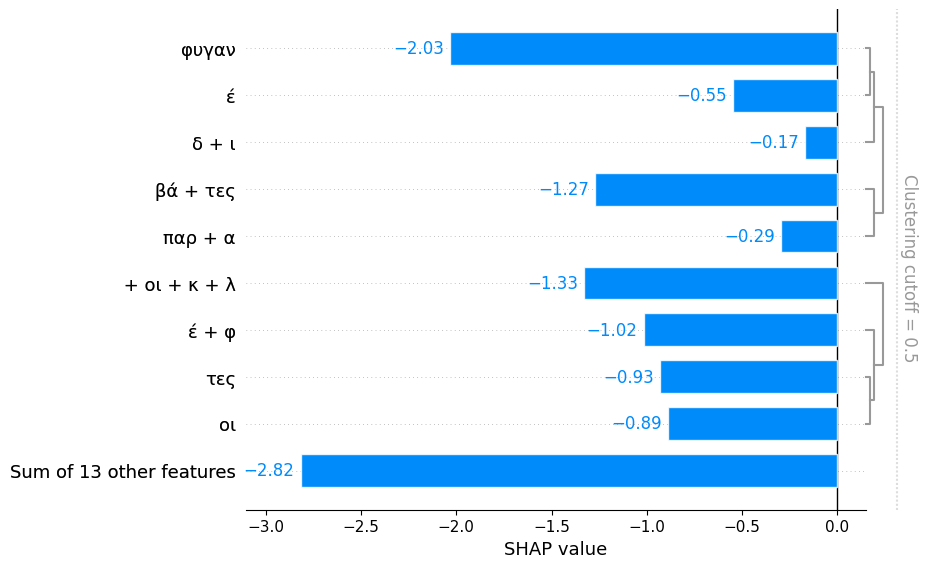

In [27]:
# Bar plot of Shap values
shap.plots.bar(shap_values[0]) # for instance 0

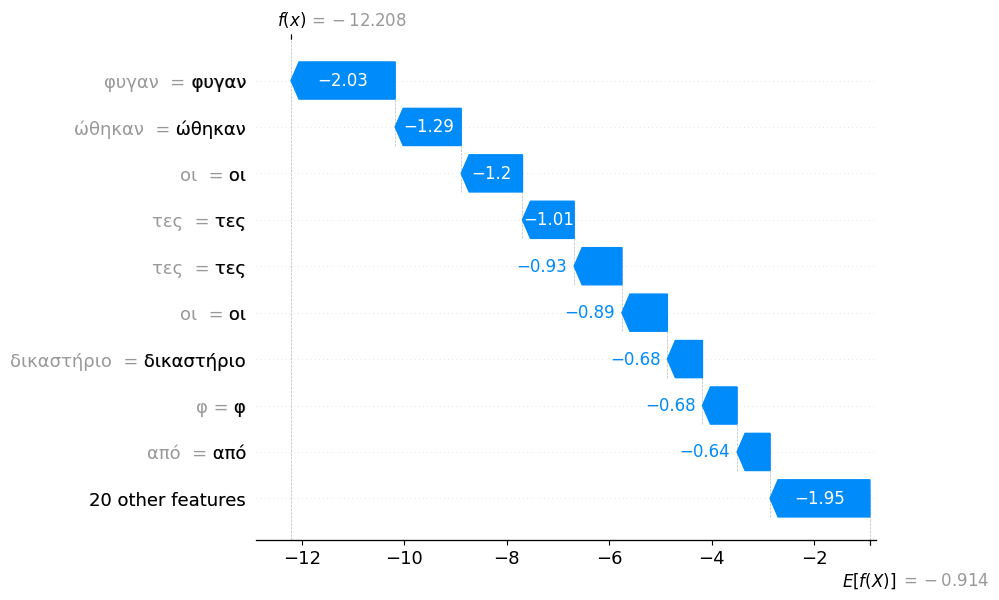

In [28]:
# Waterfall plot of Shap values
shap.plots.waterfall(shap_values[0]) # for instance 0

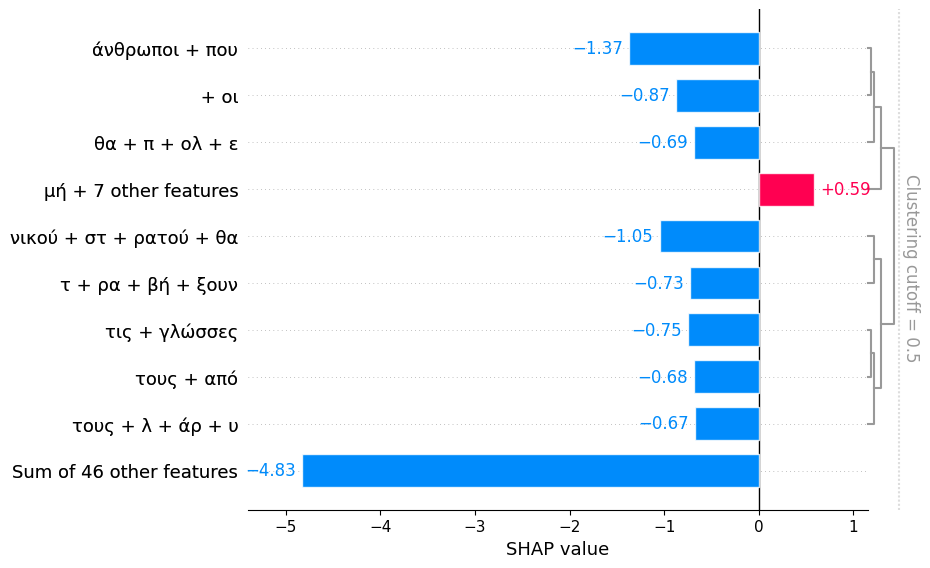

In [29]:
# Bar plot of Shap values
shap.plots.bar(shap_values[1]) # for instance 1

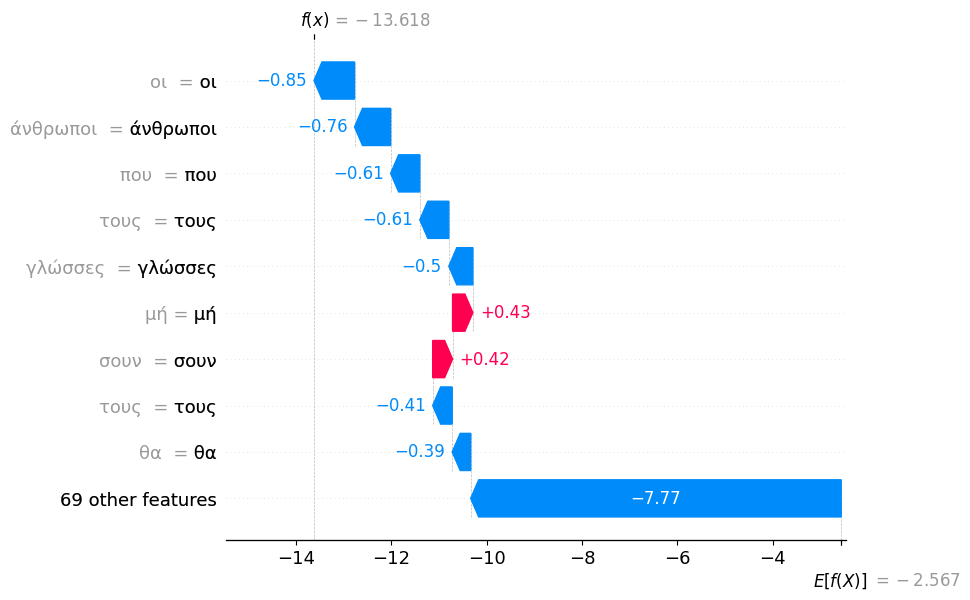

In [30]:
# Waterfall plot of Shap values
shap.plots.waterfall(shap_values[1]) # for instance 1

In [31]:
# More examples

test.head(100)

,Tweets,"Targets (1-Individual, 0-Group)",Translated_Text
0,kashmir will become pakistan india will live i...,0,το κασμίρ θα γίνει πακιστάν η ινδία θα ζήσει σ...
1,thieves miscreants escaped from the court this...,0,οι κλέφτες οι παραβάτες διέφυγαν από το δικαστ...
2,the people who will fight against the pakistan...,0,οι άνθρωποι που θα πολεμήσουν εναντίον του πακ...
3,india has threatened war and invited its own d...,0,η ινδία έχει απειλήσει με πόλεμο και έχει προκ...
4,a stone will be answered by a brick captain on...,1,μια πέτρα θα απαντηθεί με ένα τούβλο καπετάνιο...
...,...,...,...
95,they will penetrate and kill god willing,0,θα διεισδύσουν και θα σκοτώσουν θεού θέλοντος
96,we will pull out your eyes and throw them out ...,1,θα σου βγάλουμε τα μάτια και θα τα πετάξουμε έ...
97,indias threat of nuclear attack,0,η απειλή της ινδίας για πυρηνική επίθεση
98,if you raise your eyes at jonyazi you will tak...,1,αν σηκώσεις τα μάτια σου στον τζονγιάζι θα του...


In [34]:
# Explanation of the model's predictions on the test dataset
shap_values = explainer(test['Translated_Text'].values[61:63])  # instances which have labelled with group

# Plot
shap.plots.text(shap_values)

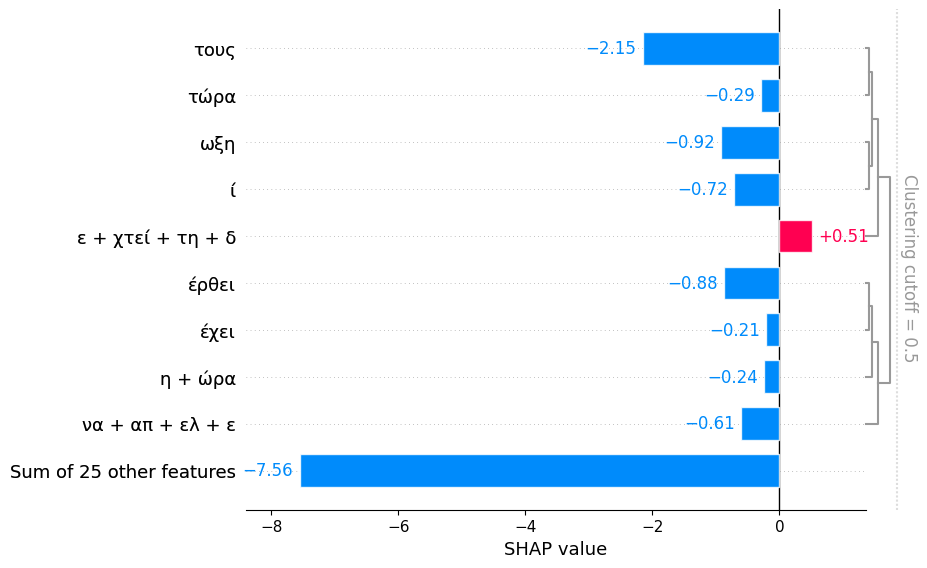

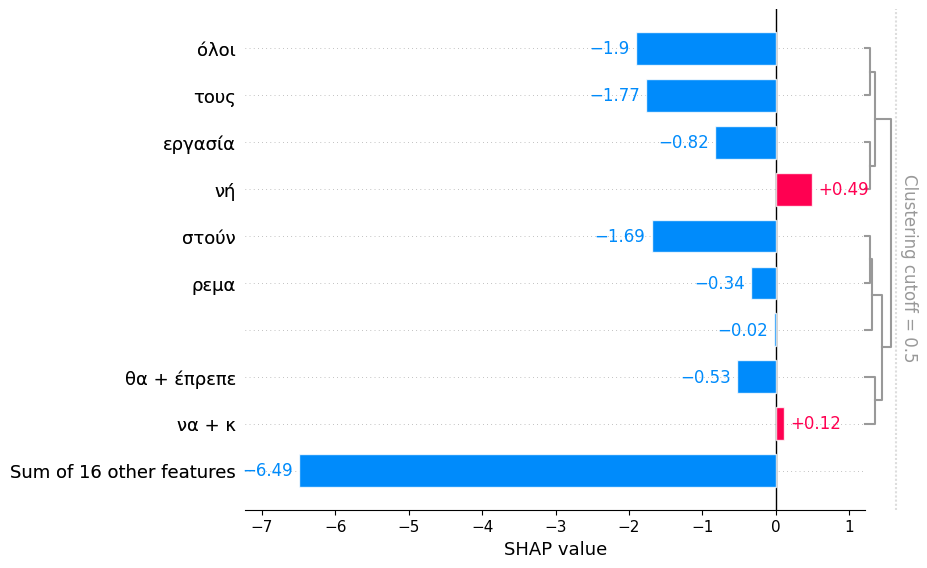

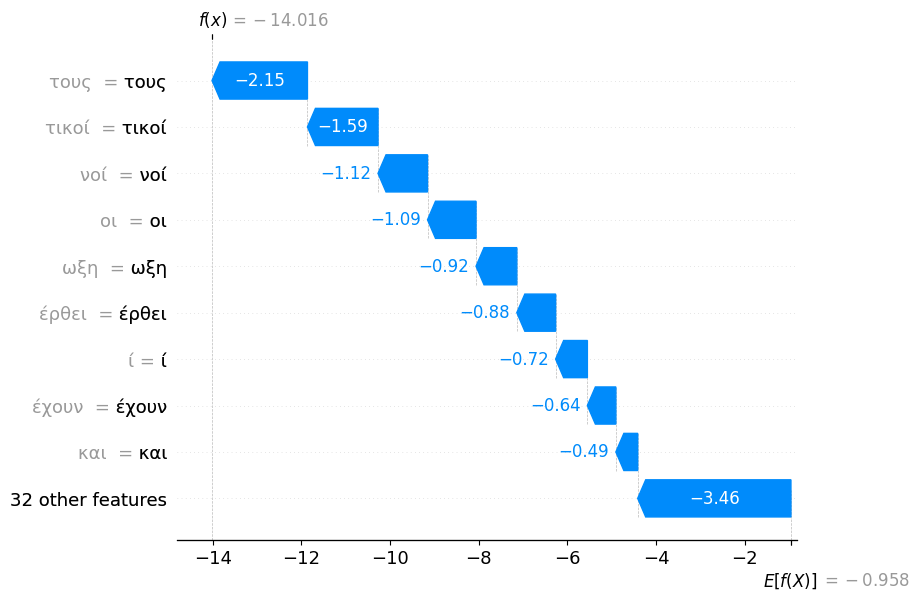

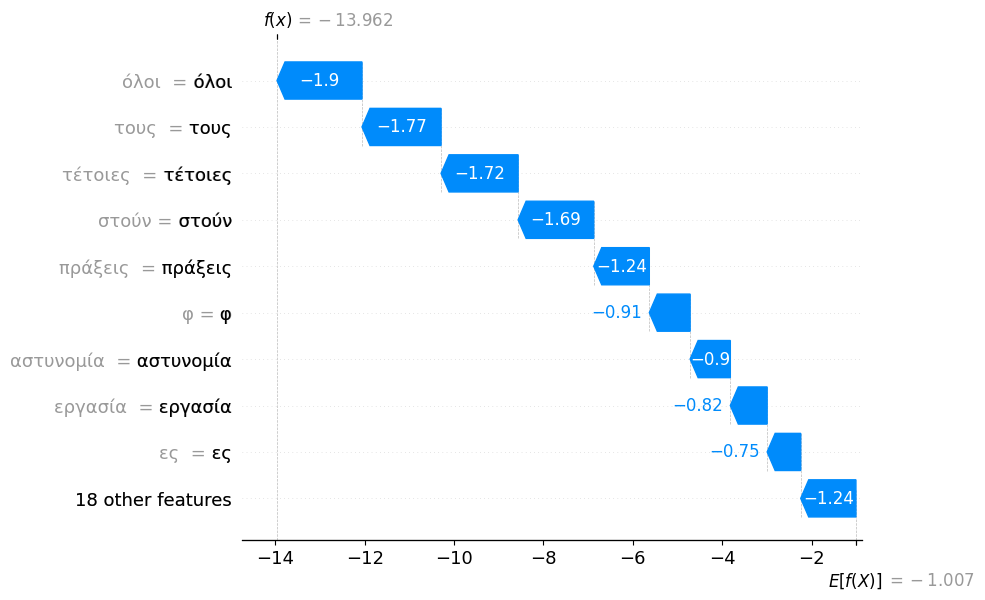

In [35]:
# Bar plot of Shap values
shap.plots.bar(shap_values[0]) # for instance 0 etc.
shap.plots.bar(shap_values[1])

# Waterfall plot of Shap values
shap.plots.waterfall(shap_values[0]) # for instance 0 etc.
shap.plots.waterfall(shap_values[1])

## Lime

In [36]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283835 sha256=58b6ea0ba1bfc03f71ebd4d3c4e69e8830013dd333a9d2ea7356181f75834dc4
  Stored in directory: /root/.cache/pip/wheels/fd/a2/af/9ac0a1a85a27f314a06b39e1f492bee1547d52549a4606ed89
Successfully built lime


In [37]:
from lime.lime_text import LimeTextExplainer
from lime import lime_text
import torch.nn.functional as F
import torch

# Evaluation mode
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

def predictor(texts):
    inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        predictions = torch.nn.functional.softmax(outputs.logits, dim=1)

    return predictions.cpu().numpy()

# LIME explainer
explainer = LimeTextExplainer(class_names=['Group', 'Individual'])

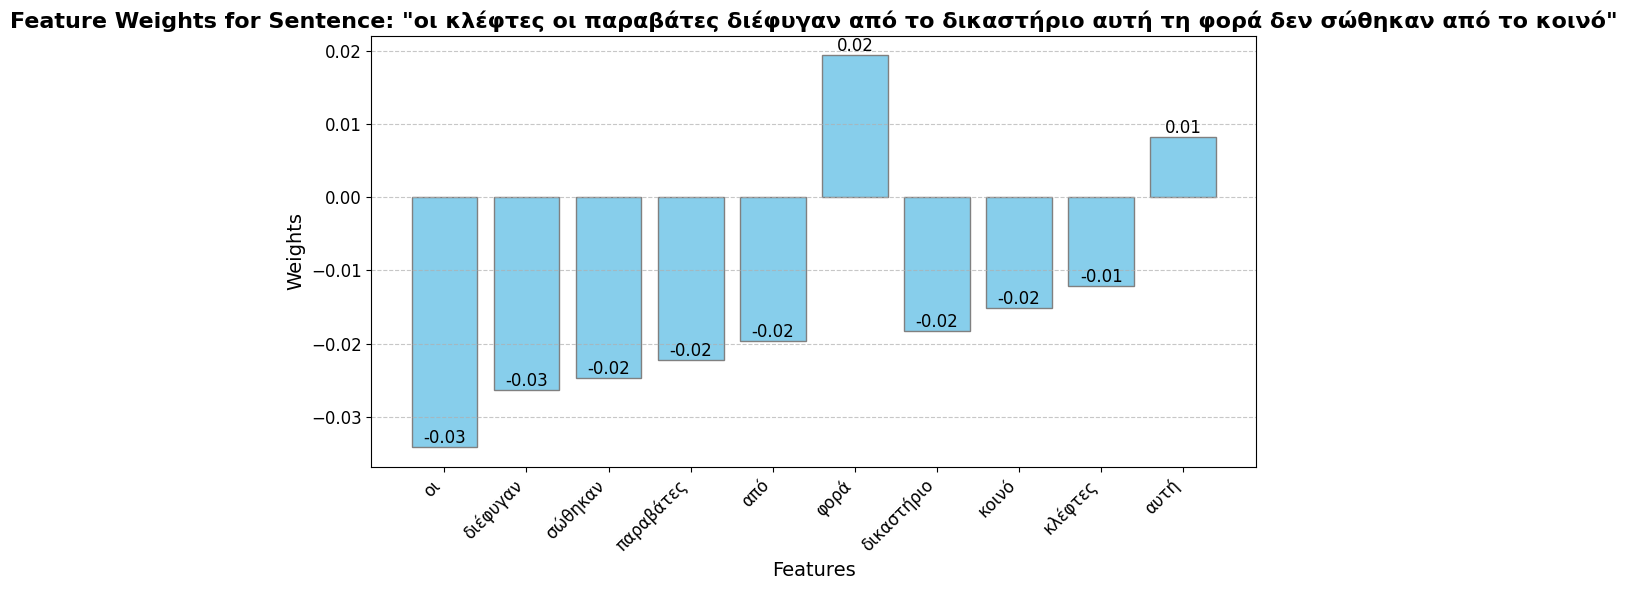

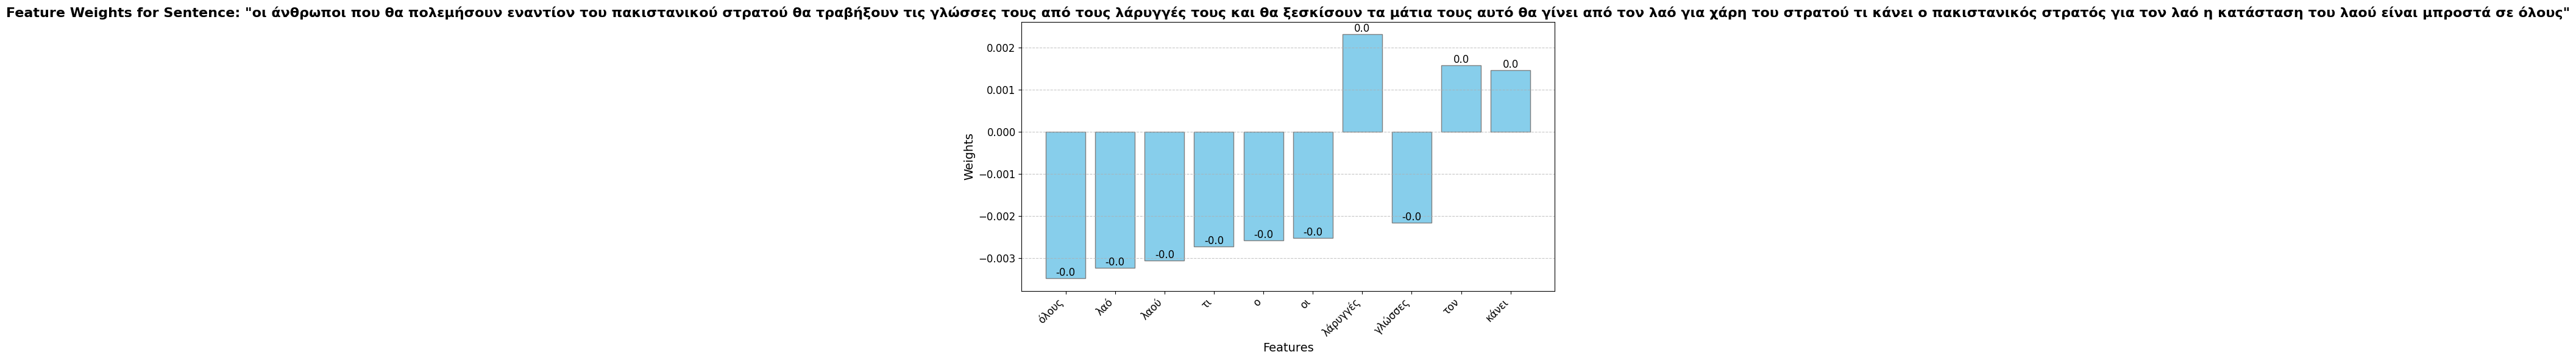

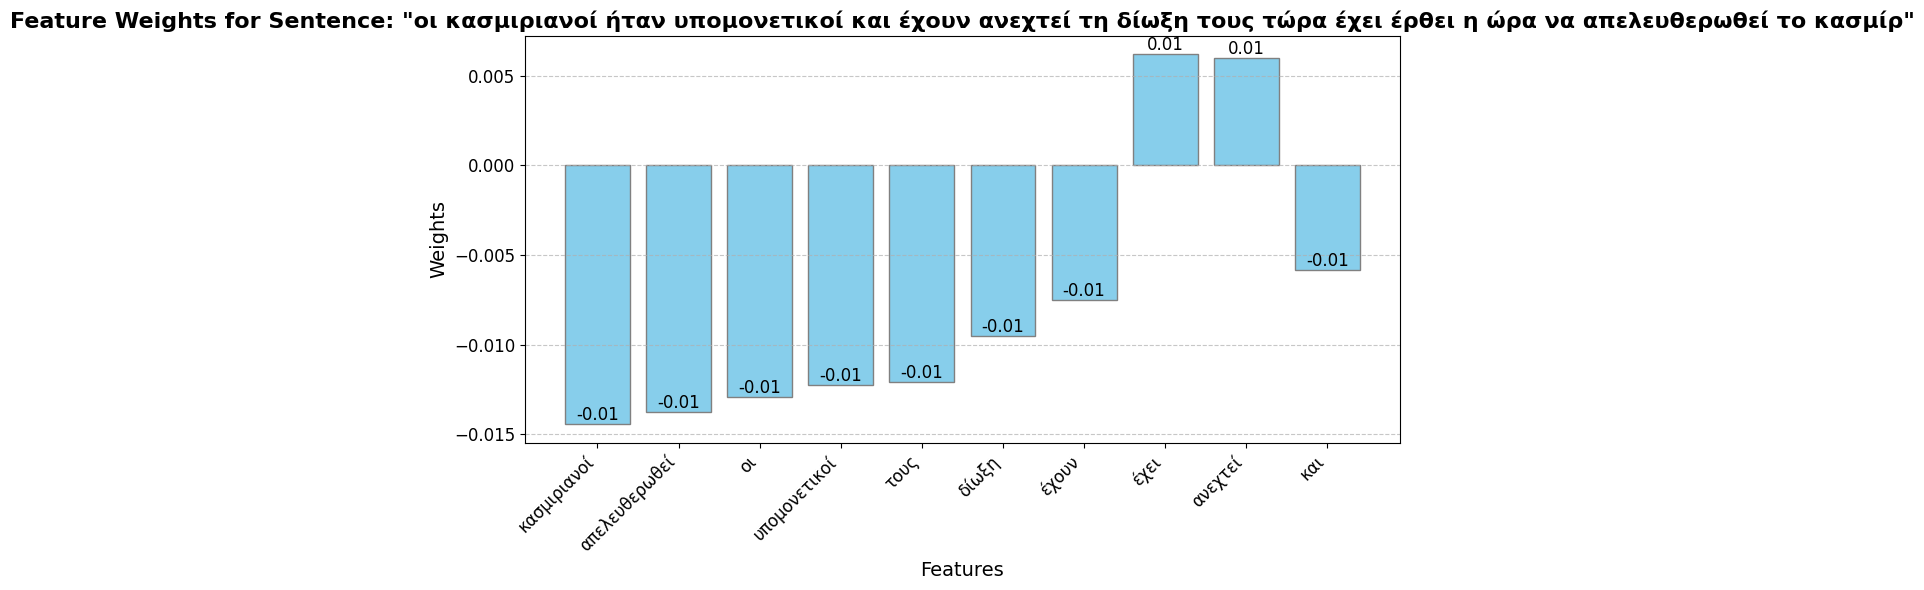

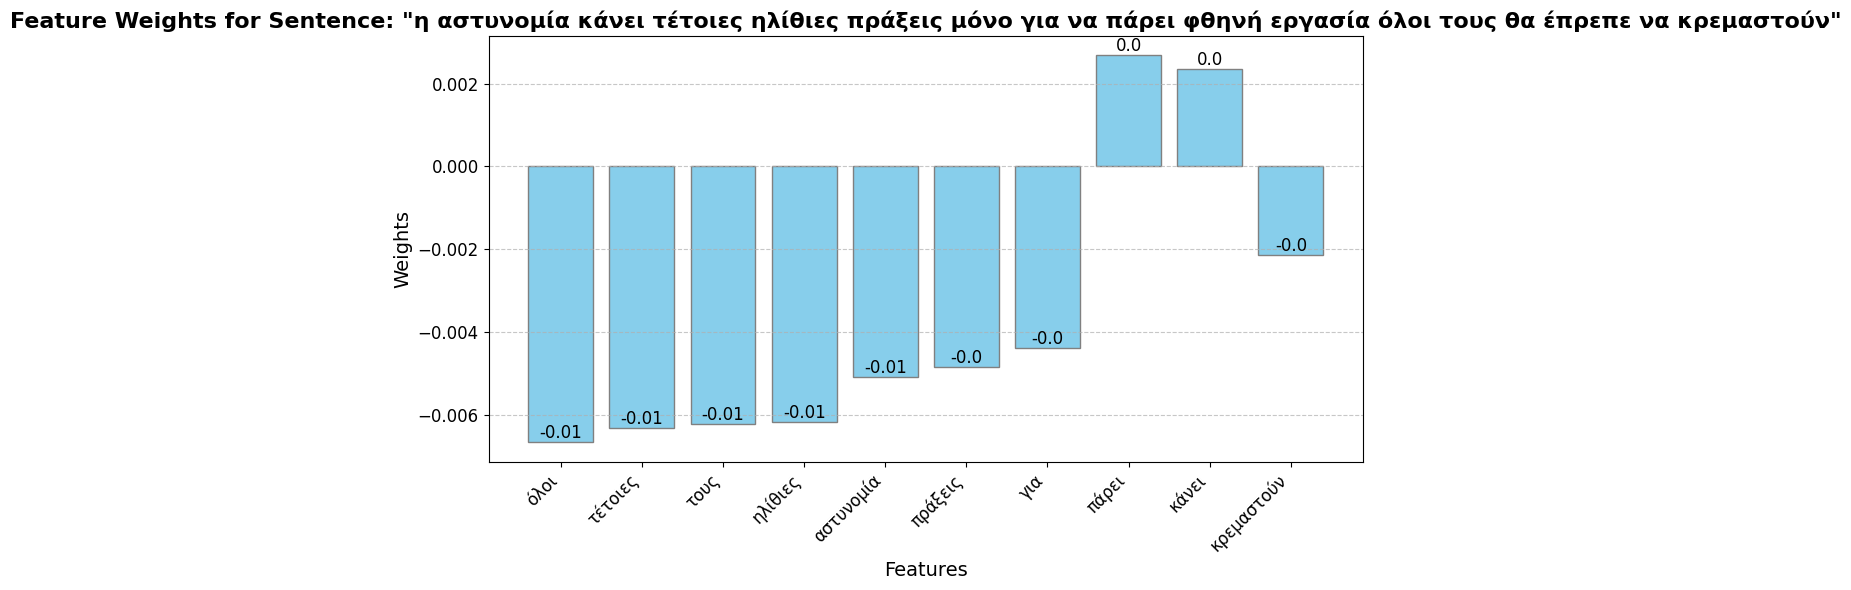

In [38]:
from lime.lime_text import LimeTextExplainer
import matplotlib.pyplot as plt
import numpy as np

# Sentences we want to explain
sentences = [
    "οι κλέφτες οι παραβάτες διέφυγαν από το δικαστήριο αυτή τη φορά δεν σώθηκαν από το κοινό",
    "οι άνθρωποι που θα πολεμήσουν εναντίον του πακιστανικού στρατού θα τραβήξουν τις γλώσσες τους από τους λάρυγγές τους και θα ξεσκίσουν τα μάτια τους αυτό θα γίνει από τον λαό για χάρη του στρατού τι κάνει ο πακιστανικός στρατός για τον λαό η κατάσταση του λαού είναι μπροστά σε όλους",
    "οι κασμιριανοί ήταν υπομονετικοί και έχουν ανεχτεί τη δίωξη τους τώρα έχει έρθει η ώρα να απελευθερωθεί το κασμίρ",
    "η αστυνομία κάνει τέτοιες ηλίθιες πράξεις μόνο για να πάρει φθηνή εργασία όλοι τους θα έπρεπε να κρεμαστούν",
]


# Function for LIME explanations
def explain_sentence(sentence):
    # Generation
    exp = explainer.explain_instance(
        sentence,
        classifier_fn=predictor,
        num_features=10,
    )

    # Display the explanation
    exp.show_in_notebook(text=True)

    # Feature names and their weights from the explanation
    feature_names = np.array([feature[0] for feature in exp.as_list()])
    weights = np.array([feature[1] for feature in exp.as_list()])

    # Top features and top weights
    num_top_features = 10
    top_features = feature_names[:num_top_features]
    top_weights = weights[:num_top_features]

    # Bar graph of classification of instances
    plt.figure(figsize=(10, 6))
    bars = plt.bar(top_features, top_weights, color='skyblue', edgecolor='grey')
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)
    plt.title(f'Feature Weights for Sentence: "{sentence}"', fontsize=16, weight='bold')
    plt.xlabel('Features', fontsize=14)
    plt.ylabel('Weights', fontsize=14)

    #gridlines
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Add value labels on top of bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval, round(yval, 2), va='bottom', fontsize=12, color='black', ha='center')

    plt.tight_layout()
    plt.show()

# explanation
for sentence in sentences:
    explain_sentence(sentence)
